# Codificación de canal mediante aprendizaje profundo
## Autoencoder de capa física (*end-to-end learning*) con PyTorch y MNIST


En este notebook reemplazamos la cadena clásica *codificador de canal → modulador → detector/decodificador* por **un único sistema entrenado de extremo a extremo**: un *autoencoder* cuyo "cuello de botella" es un **canal ruidoso**. Al terminar podrás:

1. Explicar cómo se modela un sistema de comunicaciones como un autoencoder $\;\mathbf b \xrightarrow{f_V} \mathbf x \xrightarrow{p(\mathbf y|\mathbf x)} \mathbf y \xrightarrow{f_W} \hat{\mathbf b}$.
2. Implementar una **capa de canal diferenciable** (AWGN y ruido en ráfagas) parametrizada por $E_b/N_0$.
3. Imponer una **restricción de potencia** $\mathbb E[\|\mathbf x\|^2]\le 1$ con una capa de normalización.
4. Medir la **BER vs. $E_b/N_0$** y compararla contra BPSK sin codificar y contra el código de Hamming(7,4) (decodificación dura y blanda).
5. Transmitir **imágenes MNIST binarizadas** bit a bit y *ver* el efecto de la codificación.
6. Evaluar la **robustez ante ruido en ráfagas** y mostrar que el sistema neural puede **adaptarse** a un canal para el que no existe un código "de libro".

**Contenido**

1. Introducción y dependencias
2. Carga y preparación del dataset (MNIST → bits)
3. Arquitectura del autoencoder de canal
4. Entrenamiento
5. Evaluación y visualización (5.1 BER vs. SNR · 5.2 imágenes · 5.3 ruido en ráfagas)
6. Conclusiones, limitaciones y ejercicios

> **Nota práctica.** El modelo es pequeño (MLP), por lo que corre en CPU en unos minutos; una GPU acelera sobre todo las simulaciones Monte Carlo de la sección 5. Todos los hiperparámetros están en una sola celda (sección 1) para que puedas experimentar.

## 1. Introducción y dependencias

### 1.1 Del diseño modular al aprendizaje de extremo a extremo

Shannon demostró que, para un canal con capacidad $C$, existen códigos que permiten comunicar con probabilidad de error arbitrariamente pequeña siempre que la tasa cumpla $r<C$. La **codificación de canal** logra esto añadiendo redundancia estructurada: mapeamos $K$ bits de información a $n>K$ símbolos, con **tasa** $r=K/n$. El precio es ancho de banda o energía por bit; el beneficio es la **ganancia de codificación**: la reducción de $E_b/N_0$ necesaria para alcanzar una BER objetivo respecto a transmitir sin codificar.

El diseño clásico es **modular**: cada bloque (codificador, modulador, detector, decodificador) se diseña por separado con un modelo matemático del canal. El enfoque de *end-to-end learning* (O'Shea & Hoydis, 2017) observa que la cadena completa es una composición de funciones y puede entrenarse como un **autoencoder**:

```
 b ∈ {0,1}^K ─► [ Codificador f_V ] ─► x ∈ R^n ─► [ Canal p(y|x) ] ─► y ∈ R^n ─► [ Decodificador f_W ] ─► b̂ ∈ [0,1]^K
                 (MLP + norm. de potencia)          (AWGN / ráfagas)                (MLP + sigmoide)
                 └────────── transmisor ───────────┘  └── no entrenable ──┘  └───────────── receptor ───────────────┘
```

* **Codificador neuronal $f_V$** (parámetros $V$): aprende *simultáneamente* el código y la modulación (los símbolos $\mathbf x\in\mathbb R^n$ son valores reales arbitrarios, no necesariamente $\pm1$).
* **Canal $p(\mathbf y|\mathbf x)$**: capa **estocástica sin parámetros entrenables** pero **diferenciable respecto a $\mathbf x$**. Para AWGN, $\mathbf y=\mathbf x+\mathbf w$ con $\mathbf w\sim\mathcal N(\mathbf 0,\sigma^2\mathbf I)$ (truco de reparametrización): el ruido es una entrada externa y el gradiente atraviesa la suma.
* **Decodificador neuronal $f_W$** (parámetros $W$): aprende una regla de decisión (aproximadamente MAP) para $\hat{\mathbf b}$.

### 1.2 Función de pérdida

Entrenamos con **entropía cruzada binaria** (BCE) entre los bits transmitidos y las probabilidades $\hat p_i=\sigma_{\rm sig}(\ell_i)$ que entrega el decodificador:

$$
\mathcal L(V,W)\;=\;-\,\mathbb E\Big[\sum_{i=1}^{K} b_i\log \hat p_i + (1-b_i)\log(1-\hat p_i)\Big].
$$

Esto no es una elección arbitraria: si $q(\mathbf b|\mathbf y)$ es la distribución implícita del decodificador, la BCE es una cota superior de $H(\mathbf b|\mathbf y)$, y por tanto $I(\mathbf b;\mathbf y)=H(\mathbf b)-H(\mathbf b|\mathbf y)\ge H(\mathbf b)-\mathcal L$. **Minimizar la BCE equivale a maximizar una cota inferior de la información mutua** entre lo transmitido y lo recibido, que es exactamente lo que persigue un buen código de canal.

### 1.3 Dependencias

In [ ]:
import math
import copy
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# Reproducibilidad
SEED = 2024
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | torchvision {torchvision.__version__} | dispositivo: {device}")

# ======================= HIPERPARÁMETROS (modifícalos y re-ejecuta) =======================
# --- Código ---
K      = 4          # bits de información por bloque
N_CH   = 7          # usos del canal (símbolos reales) por bloque  ->  tasa r = K / N_CH
RATE   = K / N_CH
POWER  = 1.0        # restricción de potencia: E[||x||^2] <= POWER (energía por palabra código)
HIDDEN = 64         # neuronas por capa oculta (codificador y decodificador)
NORM_MODE = "codeword"   # "codeword": ||x||^2 = POWER en cada palabra | "batch": E[||x||^2] = POWER en promedio

# --- Entrenamiento ---
TRAIN_EBN0_DB = 3.0      # Eb/N0 (dB) fijo de entrenamiento
TRAIN_STEPS   = 15_000   # iteraciones de Adam
BATCH_SIZE    = 1024
LR            = 2e-3
TRAIN_SOURCE  = "uniform"   # "uniform": bits equiprobables | "mnist": bloques extraídos de MNIST (ver sección 2)

# --- Canal con ráfagas (sección 5.3) ---
BURST_P     = 0.03    # probabilidad de que una ráfaga comience en cada símbolo
BURST_LEN   = 3       # duración de cada ráfaga (en símbolos)
BURST_RATIO = 30.0    # cociente de potencia de ruido: dentro de la ráfaga / fuera de ella
ADAPT_STEPS = 8_000   # iteraciones de re-entrenamiento sobre el canal con ráfagas

# --- Evaluación Monte Carlo ---
EBN0_GRID        = np.arange(-2, 11, 1.0)   # -2 dB ... 10 dB
EVAL_BLOCK_BATCH = 250_000                  # bloques por lote
EVAL_MAX_BLOCKS  = 2_000_000                # tope de bloques por punto de SNR
EVAL_MIN_ERRORS  = 300                      # se detiene el punto si ya se acumularon estos errores

print(f"Código ({N_CH},{K}) con tasa r = {RATE:.3f} | restricción E[||x||²] ≤ {POWER}")

PyTorch 2.11.0+cu128 | torchvision 0.26.0+cu128 | dispositivo: cuda
Código (7,4) con tasa r = 0.571 | restricción E[||x||²] ≤ 1.0


## 2. Carga y preparación del dataset (MNIST)

Usaremos **MNIST** (60 000 imágenes de entrenamiento y 10 000 de prueba de $28\times28$ píxeles) como **fuente de mensajes**:

* Cada píxel se **binariza**: $b=1$ si el nivel de gris $>127$ (trazo del dígito) y $b=0$ en caso contrario (fondo). Así, cada imagen es una secuencia de $28\cdot28=784$ bits.
* Como el codificador procesa $K$ bits a la vez, la secuencia se **parte en bloques** de $K$ bits (si $784$ no es múltiplo de $K$ se rellena con ceros al final, y esos bits de relleno se descartan al reconstruir).
* Con $K=4$ cada imagen genera $196$ bloques → $196\cdot n=1372$ símbolos por el canal.

### ¿Son "equiprobables" los bits de MNIST?

Los códigos de canal se diseñan suponiendo bits **i.i.d. equiprobables**: es la salida de un compresor (codificador de fuente) ideal, y por el **teorema de separación fuente-canal** ambos problemas pueden resolverse por separado. Las imágenes MNIST binarizadas **no** cumplen esto (la gran mayoría de los píxeles es fondo), así que hay mucha redundancia de fuente que no estamos comprimiendo. Lo cuantificamos en la siguiente celda; de ahí la decisión de diseño:

* **Por defecto** entrenamos con bits uniformes (`TRAIN_SOURCE = "uniform"`) para obtener un **código de canal general**, y usamos MNIST como fuente real en la **evaluación y la visualización**.
* Con `TRAIN_SOURCE = "mnist"` el sistema aprende a *explotar* la estadística de la fuente (codificación conjunta fuente-canal). Es un experimento interesante (ejercicio 2), pero el BER sobre bits uniformes empeorará.

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.92MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


Imágenes de entrenamiento: 60000 | de prueba: 10000
Cada imagen = 784 bits = 196 bloques de K=4 bits -> 1372 usos del canal con el código de tasa 0.571
Bloques de prueba disponibles: 1,960,000


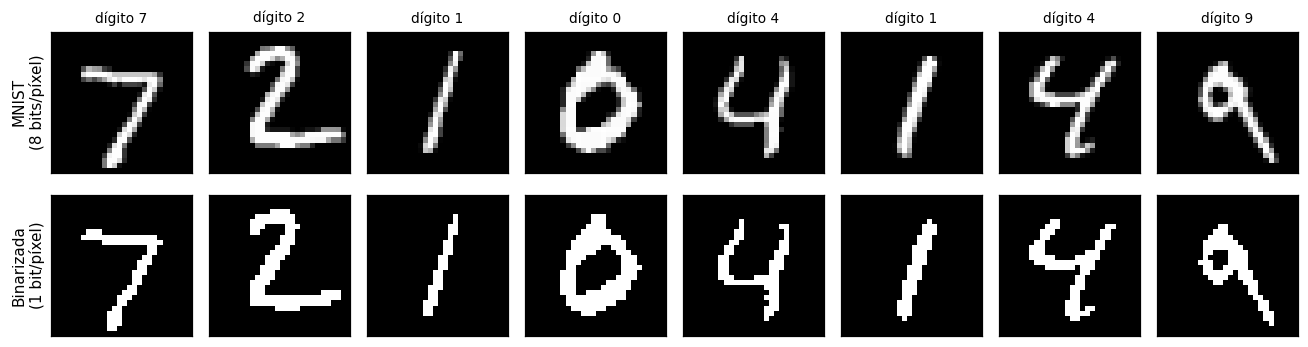

In [ ]:
IMG_SIDE   = 28
IMG_PIXELS = IMG_SIDE * IMG_SIDE      # 784 bits por imagen

# Descarga (la primera vez) y carga de MNIST con torchvision
train_ds = datasets.MNIST(root="./data", train=True,  download=True)
test_ds  = datasets.MNIST(root="./data", train=False, download=True)

# Binarización: píxel > 127  ->  bit 1 (trazo);  en otro caso  ->  bit 0 (fondo)
train_bits  = (train_ds.data > 127).to(torch.uint8)     # (60000, 28, 28)
test_bits   = (test_ds.data  > 127).to(torch.uint8)     # (10000, 28, 28)
test_labels = test_ds.targets


def bits_to_blocks(bits):
    """(N, 28, 28) -> (N, n_bloques, K).  Aplana cada imagen y la parte en bloques de K bits."""
    flat = bits.reshape(bits.shape[0], -1)
    pad = (-flat.shape[1]) % K                            # bits de relleno si 784 no es múltiplo de K
    if pad:
        flat = torch.cat([flat, flat.new_zeros(flat.shape[0], pad)], dim=1)
    return flat.reshape(flat.shape[0], -1, K)


def blocks_to_bits(blocks):
    """(N, n_bloques, K) -> (N, 28, 28).  Operación inversa (descarta el relleno)."""
    flat = blocks.reshape(blocks.shape[0], -1)[:, :IMG_PIXELS]
    return flat.reshape(-1, IMG_SIDE, IMG_SIDE)


# Datasets de bloques: cada fila es un mensaje b de K bits
train_blocks_cpu = bits_to_blocks(train_bits).reshape(-1, K)   # (60000 * n_bloques, K)
test_blocks_cpu  = bits_to_blocks(test_bits).reshape(-1, K)
train_blocks = train_blocks_cpu.to(device)
test_blocks  = test_blocks_cpu.to(device)

n_blocks_img = math.ceil(IMG_PIXELS / K)
print(f"Imágenes de entrenamiento: {len(train_bits)} | de prueba: {len(test_bits)}")
print(f"Cada imagen = {IMG_PIXELS} bits = {n_blocks_img} bloques de K={K} bits "
      f"-> {n_blocks_img * N_CH} usos del canal con el código de tasa {RATE:.3f}")
print(f"Bloques de prueba disponibles: {len(test_blocks_cpu):,}")

# --- Vista rápida: original vs. binarizada ---
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for i in range(8):
    axes[0, i].imshow(test_ds.data[i].numpy(), cmap="gray")
    axes[0, i].set_title(f"dígito {int(test_labels[i])}", fontsize=9)
    axes[1, i].imshow(test_bits[i].numpy(), cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_ylabel("MNIST\n(8 bits/píxel)")
axes[1, 0].set_ylabel("Binarizada\n(1 bit/píxel)")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()

Fracción de bits '1' en MNIST binarizado: 0.132   (una fuente equiprobable tendría 0.500)
Entropía por bit si fuera i.i.d. con esa probabilidad: 0.564 bits/bit
Entropía empírica por bloque de 4 bits: 1.48 bits  ->  0.37 bits de información por bit transmitido


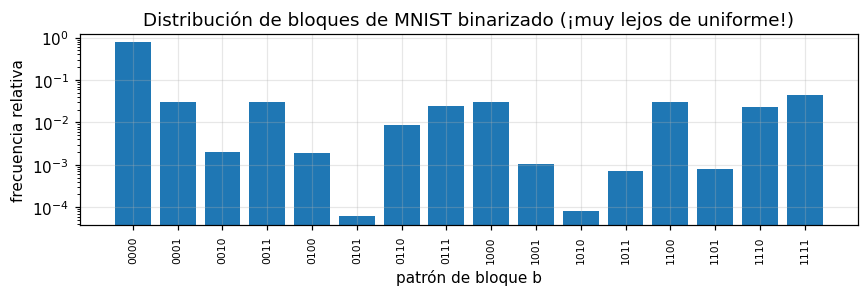

In [ ]:
# --- ¿Qué tan lejos está MNIST de una fuente binaria equiprobable? ---
p_uno = train_bits.float().mean().item()
print(f"Fracción de bits '1' en MNIST binarizado: {p_uno:.3f}   (una fuente equiprobable tendría 0.500)")
print(f"Entropía por bit si fuera i.i.d. con esa probabilidad: "
      f"{-(p_uno*math.log2(p_uno) + (1-p_uno)*math.log2(1-p_uno)):.3f} bits/bit")

if K <= 10:
    # Distribución empírica de los 2^K patrones posibles de bloque
    pesos = 2 ** torch.arange(K - 1, -1, -1)
    idx = (train_blocks_cpu[:2_000_000].long() * pesos).sum(dim=1)
    freq = torch.bincount(idx, minlength=2 ** K).float()
    freq = freq / freq.sum()
    nz = freq[freq > 0]
    H_bloque = -(nz * torch.log2(nz)).sum().item()
    print(f"Entropía empírica por bloque de {K} bits: {H_bloque:.2f} bits  ->  {H_bloque / K:.2f} bits de información por bit transmitido")

    if K <= 6:
        fig, ax = plt.subplots(figsize=(8, 2.8))
        ax.bar(range(2 ** K), freq.numpy(), color="tab:blue")
        ax.set_xticks(range(2 ** K)); ax.set_xticklabels([format(i, f"0{K}b") for i in range(2 ** K)], rotation=90, fontsize=7)
        ax.set_yscale("log"); ax.set_xlabel("patrón de bloque b"); ax.set_ylabel("frecuencia relativa")
        ax.set_title("Distribución de bloques de MNIST binarizado (¡muy lejos de uniforme!)")
        plt.tight_layout(); plt.show()

## 3. Arquitectura del autoencoder de canal

### 3.1 Relación entre $E_b/N_0$ y la varianza del ruido

La restricción de potencia es $\mathbb E[\|\mathbf x\|^2]\le P$ con $P=1$ (energía por **palabra código**). Como cada palabra transporta $K$ bits, la energía por bit es $E_b=P/K$. Con ruido de densidad espectral $N_0/2$ por dimensión real, $\sigma^2=N_0/2$ y por tanto

$$
\boxed{\;\sigma^2=\frac{N_0}{2}=\frac{P}{2K\,(E_b/N_0)}\;}\qquad (E_b/N_0 \text{ en escala lineal}).
$$

Es equivalente a la forma habitual $\sigma^2=\dfrac{1}{2r\,E_b/N_0}$ cuando se normaliza a energía unitaria *por símbolo* ($P=n$). Usar $E_b/N_0$ (y no $E_s/N_0$) es esencial: **penaliza la redundancia**. Un código de tasa $r<1$ transmite más símbolos, pero cada bit de información dispone de la misma energía $E_b$ que en el caso sin codificar; así la comparación es justa. Para BPSK sin codificar basta poner $K=1$ y $P=1$, con lo que $\sigma^2=1/(2E_b/N_0)$.

### 3.2 Bloques del sistema

| Bloque | Entrada → salida | Descripción |
|---|---|---|
| **Encoder** $f_V$ | $\{0,1\}^K\to\mathbb R^n$ | MLP de 2 capas ocultas (ReLU) + **capa de normalización de potencia** |
| **Normalización de potencia** | $\mathbb R^n\to\mathbb R^n$ | `codeword`: $\mathbf x\leftarrow\sqrt{P}\,\mathbf x/\|\mathbf x\|$ (cada palabra tiene energía $P$). `batch`: escala con la energía media del lote (y una media móvil en inferencia), de modo que se cumple $\mathbb E[\|\mathbf x\|^2]=P$ solo *en promedio* |
| **Channel layer** | $\mathbb R^n\to\mathbb R^n$ | AWGN con $\sigma$ según $E_b/N_0$; opcionalmente **ráfagas** (sección 5.3) |
| **Decoder** $f_W$ | $\mathbb R^n\to[0,1]^K$ | MLP de 2 capas ocultas (ReLU) con salida sigmoide (en entrenamiento devuelve *logits*; la sigmoide se aplica dentro de la BCE por estabilidad numérica) |

### 3.3 Modelo de ruido en ráfagas

Modelamos ruido impulsivo/en ráfagas de forma sencilla y vectorizable (estilo Gilbert-Elliott): en cada símbolo *comienza* una ráfaga con probabilidad `BURST_P`; cada ráfaga dura `BURST_LEN` símbolos consecutivos. Durante una ráfaga la varianza del ruido es `BURST_RATIO` veces mayor que fuera de ella. Además **normalizamos las varianzas para que la potencia media de ruido sea exactamente $\sigma^2$** (la misma que en AWGN al mismo $E_b/N_0$). Así, cualquier diferencia de BER se debe únicamente a la **estructura temporal** del ruido y no a que haya "más ruido".

Sea $\pi=1-(1-p)^{L}$ la fracción de símbolos afectados por alguna ráfaga. Las varianzas resultan
$$
\sigma_g^2=\frac{\sigma^2}{1-\pi+\pi\rho},\qquad \sigma_b^2=\rho\,\sigma_g^2,
$$
con $\rho=$ `BURST_RATIO`, de modo que $(1-\pi)\sigma_g^2+\pi\sigma_b^2=\sigma^2$. El proceso de ráfagas corre a lo largo de la **secuencia continua de símbolos transmitidos** (el canal no "sabe" dónde empiezan las palabras código).

In [ ]:
# ----------------------------------------------------------------------------------------
#  Utilidades de canal
# ----------------------------------------------------------------------------------------
def noise_sigma(ebn0_db, k_bits, block_energy=1.0):
    """Desviación estándar del ruido por dimensión real: sigma^2 = P / (2 K Eb/N0)."""
    ebn0 = 10.0 ** (ebn0_db / 10.0)
    return math.sqrt(block_energy / (2.0 * k_bits * ebn0))


def burst_mask(n_symbols, p_start, burst_len, dev):
    """Máscara {0,1} de longitud n_symbols: 1 = símbolo dentro de una ráfaga.
    Cada símbolo inicia una ráfaga con prob. p_start; la ráfaga dura burst_len símbolos.
    Vectorizado: max-pooling de ventana burst_len sobre los instantes de inicio."""
    starts = (torch.rand(1, 1, n_symbols, device=dev) < p_start).float()
    starts = F.pad(starts, (burst_len - 1, 0))            # relleno a la izquierda (causal)
    mask = F.max_pool1d(starts, kernel_size=burst_len, stride=1)
    return mask.reshape(-1)


class ChannelLayer(nn.Module):
    """Capa de canal diferenciable (sin parámetros entrenables).

    kind = "awgn"  : y = x + w,  w ~ N(0, sigma^2)
    kind = "burst" : y = x + w,  con varianza alta durante las ráfagas y baja fuera de ellas,
                     manteniendo la potencia media de ruido igual a la del canal AWGN.
    k_bits, block_energy: definen la relación Eb/N0 (Eb = block_energy / k_bits)."""

    def __init__(self, k_bits, block_energy=1.0, kind="awgn",
                 p_start=BURST_P, burst_len=BURST_LEN, ratio=BURST_RATIO):
        super().__init__()
        self.k_bits, self.block_energy, self.kind = k_bits, block_energy, kind
        self.p_start, self.burst_len, self.ratio = p_start, burst_len, ratio

    def forward(self, x, ebn0_db):
        sigma = noise_sigma(ebn0_db, self.k_bits, self.block_energy)
        if self.kind == "awgn":
            return x + sigma * torch.randn_like(x)      # truco de reparametrización

        # --- ruido en ráfagas (misma potencia media que AWGN) ---
        pi = 1.0 - (1.0 - self.p_start) ** self.burst_len
        sigma_g = sigma / math.sqrt(1.0 - pi + pi * self.ratio)   # fuera de ráfaga
        sigma_b = sigma_g * math.sqrt(self.ratio)                 # dentro de ráfaga
        mask = burst_mask(x.numel(), self.p_start, self.burst_len, x.device).reshape(x.shape)
        sig = sigma_g + (sigma_b - sigma_g) * mask                # desviación estándar por símbolo
        return x + sig * torch.randn_like(x)


# ----------------------------------------------------------------------------------------
#  Codificador, decodificador y autoencoder completo
# ----------------------------------------------------------------------------------------
class PowerNormalization(nn.Module):
    """Impone la restricción de potencia sobre las palabras código x (forma (B, n))."""

    def __init__(self, power=1.0, mode="codeword", momentum=0.1):
        super().__init__()
        self.power, self.mode, self.momentum = power, mode, momentum
        self.register_buffer("running_energy", torch.tensor(float(power)))

    def forward(self, x):
        if self.mode == "codeword":
            # Restricción "dura": ||x||^2 = P para CADA palabra código (=> E[||x||^2] = P)
            energy = x.pow(2).sum(dim=1, keepdim=True)
        else:
            # Restricción "en promedio": E[||x||^2] = P sobre el lote (como BatchNorm).
            # En inferencia se usa una media móvil, para no depender de qué mensajes haya en el lote.
            if self.training:
                energy = x.pow(2).sum(dim=1).mean()
                with torch.no_grad():
                    self.running_energy.mul_(1 - self.momentum).add_(self.momentum * energy.detach())
            else:
                energy = self.running_energy
        return x * torch.sqrt(self.power / (energy + 1e-12))


class Encoder(nn.Module):
    """f_V : K bits -> n símbolos reales, con restricción de potencia."""

    def __init__(self, k, n, hidden=64, power=1.0, norm_mode="codeword"):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(k, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n),
        )
        self.norm = PowerNormalization(power, norm_mode)

    def forward(self, bits):
        return self.norm(self.net(2.0 * bits - 1.0))       # bits {0,1} -> {-1,+1} (entrada centrada)


class Decoder(nn.Module):
    """f_W : n símbolos ruidosos -> K logits (probabilidad de cada bit = sigmoide(logit))."""

    def __init__(self, n, k, hidden=64, power=1.0):
        super().__init__()
        self.scale = math.sqrt(n / power)      # ganancia fija (AGC): deja las entradas con amplitud ~ 1
        self.net = nn.Sequential(
            nn.Linear(n, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, k),
        )

    def forward(self, y):
        return self.net(y * self.scale)                     # logits (sin sigmoide)

    def probabilities(self, y):
        return torch.sigmoid(self.forward(y))               # estimación de P(b_i = 1 | y)

    def predict_bits(self, y):
        return (self.probabilities(y) > 0.5).float()        # decisión dura sobre la salida sigmoide


class ChannelAutoencoder(nn.Module):
    """Autoencoder de capa física:  b -> f_V -> x -> canal -> y -> f_W -> logits de b̂."""

    def __init__(self, k, n, hidden=64, power=1.0, norm_mode="codeword", channel=None):
        super().__init__()
        self.encoder = Encoder(k, n, hidden, power, norm_mode)
        self.channel = channel if channel is not None else ChannelLayer(k, power, "awgn")
        self.decoder = Decoder(n, k, hidden, power)

    def forward(self, bits, ebn0_db):
        x = self.encoder(bits)
        y = self.channel(x, ebn0_db)
        return self.decoder(y)


model = ChannelAutoencoder(K, N_CH, HIDDEN, POWER, NORM_MODE).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nParámetros entrenables: {n_params:,}")

ChannelAutoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=7, bias=True)
    )
    (norm): PowerNormalization()
  )
  (channel): ChannelLayer()
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=7, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=4, bias=True)
    )
  )
)

Parámetros entrenables: 9,867


Eb/N0 = 6.0 dB  ->  sigma^2 teórica          = 0.03140
                           varianza empírica AWGN   = 0.03139
                           varianza empírica ráfaga = 0.03137   (misma potencia media)
Fracción de símbolos en ráfaga: teórica 0.0873 | empírica 0.0870


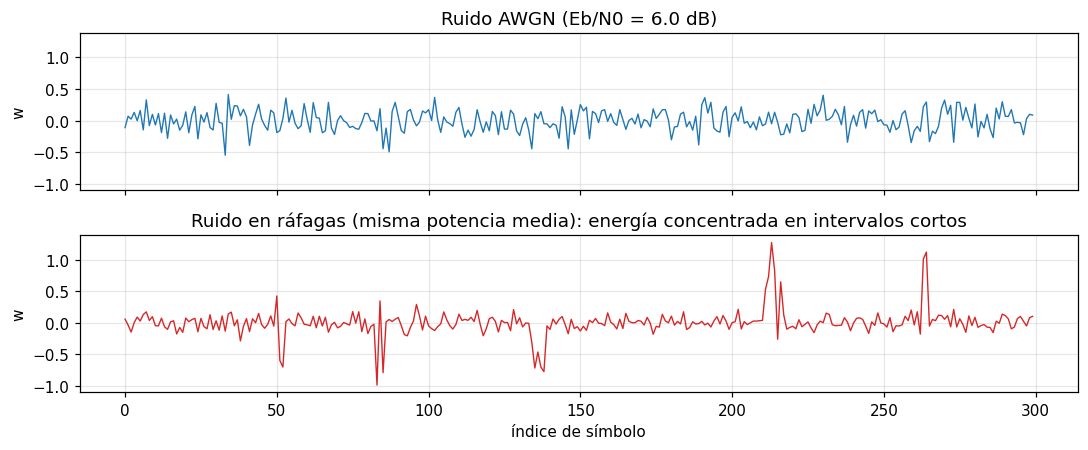

In [ ]:
# ----------------------------------------------------------------------------------------
#  Verificación de la capa de canal: ¿la potencia de ruido coincide con la teoría?
# ----------------------------------------------------------------------------------------
ch_awgn_demo  = ChannelLayer(K, POWER, "awgn")
ch_burst_demo = ChannelLayer(K, POWER, "burst")

gamma_db   = 6.0
sigma2_teo = noise_sigma(gamma_db, K, POWER) ** 2

ceros   = torch.zeros(1, 2_000_000)               # transmitimos "nada": lo que sale es ruido puro
w_awgn  = ch_awgn_demo(ceros, gamma_db)
w_burst = ch_burst_demo(ceros, gamma_db)
pi_teo  = 1 - (1 - BURST_P) ** BURST_LEN
pi_emp  = burst_mask(ceros.numel(), BURST_P, BURST_LEN, ceros.device).mean().item()

print(f"Eb/N0 = {gamma_db} dB  ->  sigma^2 teórica          = {sigma2_teo:.5f}")
print(f"                           varianza empírica AWGN   = {w_awgn.var().item():.5f}")
print(f"                           varianza empírica ráfaga = {w_burst.var().item():.5f}   (misma potencia media)")
print(f"Fracción de símbolos en ráfaga: teórica {pi_teo:.4f} | empírica {pi_emp:.4f}")

fig, ax = plt.subplots(2, 1, figsize=(10, 4.2), sharex=True, sharey=True)
ax[0].plot(w_awgn[0, :300].numpy(), lw=0.9)
ax[0].set_title(f"Ruido AWGN (Eb/N0 = {gamma_db} dB)")
ax[1].plot(w_burst[0, :300].numpy(), lw=0.9, color="tab:red")
ax[1].set_title("Ruido en ráfagas (misma potencia media): energía concentrada en intervalos cortos")
ax[1].set_xlabel("índice de símbolo"); ax[0].set_ylabel("w"); ax[1].set_ylabel("w")
plt.tight_layout(); plt.show()

## 4. Entrenamiento

Entrenamos codificador y decodificador **conjuntamente** minimizando la BCE con Adam. En cada iteración:

1. se toma un lote de mensajes $\mathbf b$ (bits uniformes o bloques de MNIST),
2. se propaga por $f_V\to$ canal $\to f_W$ (con un **nuevo ruido** en cada lote: el canal es una fuente de aleatoriedad, no un dataset fijo),
3. se calcula la BCE y se retropropaga **a través del canal** hasta los parámetros del codificador.

### Elección del $E_b/N_0$ de entrenamiento

El decodificador es una función de $\mathbf y$ *ajustada a una varianza de ruido concreta*. Si se entrena con $E_b/N_0$ demasiado alto casi no hay errores y el gradiente es poco informativo (el código no aprende a proteger los bits); si es demasiado bajo, se aprende un código muy conservador que desperdicia margen a SNR alto. En la práctica se elige un valor **intermedio, en la región donde la BER es del orden de $10^{-2}$–$10^{-1}$** y se comprueba la generalización a todo el rango de SNR. Aquí usamos `TRAIN_EBN0_DB = 3` dB (ejercicio 3: barrer este parámetro).

> La decisión de bit se toma con umbral $0.5$ sobre la salida sigmoide, que equivale a signo del *logit*.

Entrenando a Eb/N0 = 3.0 dB con fuente 'uniform' ...
  paso      1/15000 | BCE = 0.6969 | BER (lote) = 0.5168 |   0.7 s
  paso   2500/15000 | BCE = 0.0450 | BER (lote) = 0.0165 |   7.4 s
  paso   5000/15000 | BCE = 0.0412 | BER (lote) = 0.0152 |  14.0 s
  paso   7500/15000 | BCE = 0.0405 | BER (lote) = 0.0148 |  20.6 s
  paso  10000/15000 | BCE = 0.0394 | BER (lote) = 0.0144 |  27.2 s
  paso  12500/15000 | BCE = 0.0389 | BER (lote) = 0.0142 |  33.9 s
  paso  15000/15000 | BCE = 0.0388 | BER (lote) = 0.0141 |  40.8 s


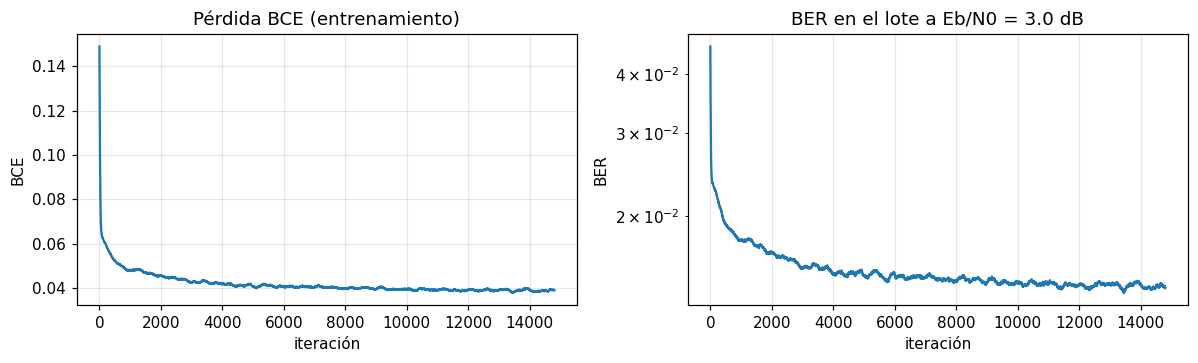

In [ ]:
def sample_bits(batch_size, source="uniform"):
    """Lote de mensajes b (float 0/1) de forma (batch_size, K)."""
    if source == "uniform":
        return torch.randint(0, 2, (batch_size, K), device=device).float()
    if source == "mnist":
        idx = torch.randint(0, train_blocks.shape[0], (batch_size,), device=device)
        return train_blocks[idx].float()
    raise ValueError("source debe ser 'uniform' o 'mnist'")


def train_autoencoder(net, ebn0_db, steps, batch_size, lr, source="uniform", log_every=2500):
    """Entrena el autoencoder end-to-end con BCE. Devuelve las curvas de pérdida y BER de entrenamiento."""
    net.train()
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=steps, eta_min=lr * 0.01)
    loss_fn = nn.BCEWithLogitsLoss()             # sigmoide + entropía cruzada binaria, numéricamente estable
    losses, bers = [], []
    t0 = time.time()
    for step in range(1, steps + 1):
        bits = sample_bits(batch_size, source)
        logits = net(bits, ebn0_db)              # b -> f_V -> canal -> f_W
        loss = loss_fn(logits, bits)

        opt.zero_grad()
        loss.backward()                          # el gradiente atraviesa el canal (y = x + w)
        opt.step()
        sched.step()

        losses.append(loss.item())
        bers.append(((logits.detach() > 0).float() != bits).float().mean().item())
        if step % log_every == 0 or step == 1:
            print(f"  paso {step:6d}/{steps} | BCE = {np.mean(losses[-500:]):.4f} | "
                  f"BER (lote) = {np.mean(bers[-500:]):.4f} | {time.time() - t0:5.1f} s")
    net.eval()
    return {"loss": np.array(losses), "ber": np.array(bers)}


print(f"Entrenando a Eb/N0 = {TRAIN_EBN0_DB} dB con fuente '{TRAIN_SOURCE}' ...")
history = train_autoencoder(model, TRAIN_EBN0_DB, TRAIN_STEPS, BATCH_SIZE, LR, TRAIN_SOURCE)

# --- Curvas de aprendizaje (suavizadas con media móvil) ---
def smooth(a, w=200):
    return np.convolve(a, np.ones(w) / w, mode="valid")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(smooth(history["loss"])); ax[0].set_title("Pérdida BCE (entrenamiento)")
ax[0].set_xlabel("iteración"); ax[0].set_ylabel("BCE")
ax[1].semilogy(smooth(history["ber"])); ax[1].set_title(f"BER en el lote a Eb/N0 = {TRAIN_EBN0_DB} dB")
ax[1].set_xlabel("iteración"); ax[1].set_ylabel("BER")
plt.tight_layout(); plt.show()

## 5. Evaluación y visualización

### 5.1 Curva BER vs. $E_b/N_0$

La **tasa de error de bits** se estima por Monte Carlo: para cada $E_b/N_0$ se transmiten bloques hasta acumular suficientes errores (`EVAL_MIN_ERRORS`) o alcanzar un tope de bloques. Para que la BER sea significativa hacen falta muchos errores (con $N_e$ errores la incertidumbre relativa es ≈$1/\sqrt{N_e}$: 100 errores dan ≈10 %, 300 dan ≈6 %); por eso el tope limita la BER mínima que se puede medir (~$10^{-6}$–$10^{-7}$ con la configuración por defecto).

Comparamos cuatro sistemas, **todos con la misma definición de $E_b/N_0$** (la energía por bit *de información*):

| Sistema | Tasa | Descripción |
|---|---|---|
| **BPSK sin codificar** | 1 | Referencia. Teoría: $P_b=Q\big(\sqrt{2E_b/N_0}\big)$ |
| **Hamming(7,4) — decisión dura** | 4/7 | Código de bloque clásico; se decide símbolo a símbolo y se corrige 1 error por síndrome |
| **Hamming(7,4) — decisión blanda (ML)** | 4/7 | Mismo código, decodificador de máxima verosimilitud sobre las 16 palabras (mínima distancia euclídea): cota práctica de lo que puede lograr *este* código |
| **Autoencoder** | 4/7 | Código **y** decodificador aprendidos |

Los sistemas de Hamming solo se incluyen si $(n,K)=(7,4)$.

**Qué observar.** Para una BER objetivo (p. ej. $10^{-3}$), la *distancia horizontal* entre dos curvas es la **ganancia de codificación** en dB. A $E_b/N_0$ bajo, un código de tasa $<1$ con decisión dura puede incluso ser *peor* que no codificar (cada símbolo recibe menos energía, $rE_b$); la decisión blanda mitiga esa pérdida y supera a BPSK sin codificar a partir de unos pocos dB.

In [ ]:
# ----------------------------------------------------------------------------------------
#  Sistemas de referencia (baselines) y simulación Monte Carlo
# ----------------------------------------------------------------------------------------
def all_messages(k):
    """Los 2^k mensajes posibles como matriz (2^k, k), MSB primero."""
    idx = torch.arange(2 ** k)
    return ((idx.unsqueeze(1) >> torch.arange(k - 1, -1, -1)) & 1).float()


HAS_HAMMING = (K == 4 and N_CH == 7)
if HAS_HAMMING:
    # Hamming(7,4) sistemático: G = [I | P],  H = [P^T | I]
    P_MAT = torch.tensor([[1, 1, 0], [1, 0, 1], [0, 1, 1], [1, 1, 1]], dtype=torch.float32)
    G_MAT = torch.cat([torch.eye(4), P_MAT], dim=1).to(device)          # (4, 7)
    H_MAT = torch.cat([P_MAT.t(), torch.eye(3)], dim=1).to(device)      # (3, 7)
    assert torch.all((G_MAT @ H_MAT.t()) % 2 == 0)                      # G H^T = 0 (mod 2)

    # Tabla síndrome -> patrón de error de un solo bit (el síndrome de un error en la posición j es la columna j de H)
    SYND_TABLE = torch.zeros(8, 7, device=device)
    for j in range(7):
        s = int(H_MAT[0, j]) * 4 + int(H_MAT[1, j]) * 2 + int(H_MAT[2, j])
        SYND_TABLE[s, j] = 1.0
    SYND_W = torch.tensor([4.0, 2.0, 1.0], device=device)

    HAM_MSGS = all_messages(4).to(device)                # (16, 4)
    HAM_CODE = (HAM_MSGS @ G_MAT) % 2                    # (16, 7) palabras código binarias
    HAM_BPSK = 2 * HAM_CODE - 1                          # (16, 7) en {-1, +1}  (energía por palabra = 7)


# Un "esquema" es una función  scheme(bits (B,K), ebn0_db) -> bits estimados (B,K).
def make_uncoded_scheme(channel):
    """BPSK sin codificar: cada bit es un símbolo ±1 (Eb = 1)."""
    def scheme(bits, ebn0_db):
        y = channel(2.0 * bits - 1.0, ebn0_db)
        return (y > 0).float()
    return scheme


def make_hamming_scheme(channel, decoder="soft"):
    """Hamming(7,4) + BPSK.  decoder = 'soft' (ML, mínima distancia) o 'hard' (síndrome)."""
    def scheme(bits, ebn0_db):
        c = (bits @ G_MAT) % 2
        y = channel(2.0 * c - 1.0, ebn0_db)
        if decoder == "soft":
            best = (y @ HAM_BPSK.t()).argmax(dim=1)          # correlación máxima = mínima distancia (energías iguales)
            return HAM_MSGS[best]
        r = (y > 0).float()                                  # decisión dura por símbolo
        s = (r @ H_MAT.t()) % 2                              # síndrome
        s_int = (s @ SYND_W).long()
        corrected = (r + SYND_TABLE[s_int]) % 2              # corrige un bit si el síndrome != 0
        return corrected[:, :4]
    return scheme


def make_ae_scheme(net, channel=None):
    """Autoencoder entrenado. Si se pasa 'channel', se sustituye el canal del modelo (para pruebas de robustez)."""
    ch = channel if channel is not None else net.channel
    def scheme(bits, ebn0_db):
        x = net.encoder(bits)
        y = ch(x, ebn0_db)
        return net.decoder.predict_bits(y)                   # sigmoide + umbral 0.5
    return scheme


def uniform_source(batch):
    return torch.randint(0, 2, (batch, K), device=device).float()

def mnist_source(batch):
    idx = torch.randint(0, test_blocks.shape[0], (batch,), device=device)
    return test_blocks[idx].float()


@torch.no_grad()
def ber_curve(scheme, ebn0_grid, source=uniform_source,
              block_batch=EVAL_BLOCK_BATCH, max_blocks=EVAL_MAX_BLOCKS, min_errors=EVAL_MIN_ERRORS):
    """BER por Monte Carlo para cada Eb/N0 de la rejilla."""
    out = []
    for snr in ebn0_grid:
        errors, total, done = 0, 0, 0
        while done < max_blocks and errors < min_errors:
            bits = source(block_batch)
            est = scheme(bits, float(snr))
            errors += (est != bits).sum().item()
            total += bits.numel()
            done += block_batch
        out.append(errors / total)
    return np.array(out)


def q_bpsk(ebn0_db):
    """Probabilidad de error teórica de BPSK en AWGN: Q(sqrt(2 Eb/N0)) = 0.5 erfc(sqrt(Eb/N0))."""
    return 0.5 * math.erfc(math.sqrt(10.0 ** (ebn0_db / 10.0)))


STYLES = {
    "unc":      dict(color="gray",       marker="o", ls="-"),
    "ham_hard": dict(color="tab:orange", marker="s", ls="-"),
    "ham_soft": dict(color="tab:green",  marker="^", ls="-"),
    "ae":       dict(color="tab:blue",   marker="D", ls="-"),
    "ae_burst": dict(color="tab:red",    marker="v", ls="--"),
    "ae_adapt": dict(color="tab:purple", marker="P", ls="-"),
}

def plot_ber(ax, grid, curves, title, theory=False):
    """curves: dict etiqueta -> (BER, clave de estilo)."""
    if theory:
        ax.semilogy(grid, [q_bpsk(g) for g in grid], "k:", lw=1.2, label="BPSK teórico  Q(√(2Eb/N0))")
    for label, (ber, key) in curves.items():
        b = np.where(ber > 0, ber, np.nan)                   # BER = 0 no se puede graficar en escala log
        ax.semilogy(grid, b, label=label, markersize=5, lw=1.5, **STYLES[key])
    ax.set_xlabel("Eb/N0 (dB)"); ax.set_ylabel("BER")
    ax.set_ylim(3e-7, 1); ax.set_title(title); ax.legend(fontsize=8, loc="lower left")

Simulación terminada en 0.3 s


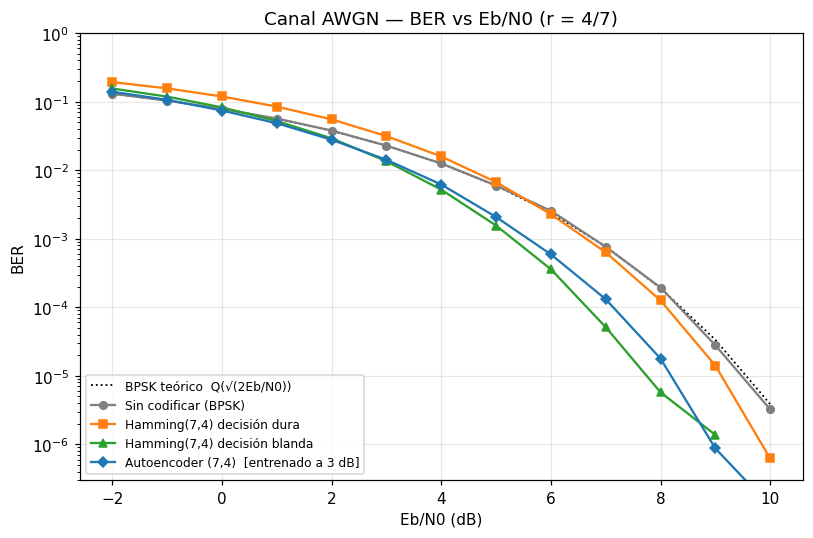


Eb/N0[dB] |       Sin codificar (BPSK) | Hamming(7,4) decisión dura | Hamming(7,4) decisión blan | Autoencoder (7,4)  [entren
     -2.0 |                   1.31e-01 |                   1.93e-01 |                   1.56e-01 |                   1.40e-01
     -1.0 |                   1.04e-01 |                   1.56e-01 |                   1.18e-01 |                   1.06e-01
      0.0 |                   7.82e-02 |                   1.19e-01 |                   8.25e-02 |                   7.43e-02
      1.0 |                   5.68e-02 |                   8.47e-02 |                   5.21e-02 |                   4.84e-02
      2.0 |                   3.79e-02 |                   5.52e-02 |                   2.92e-02 |                   2.78e-02
      3.0 |                   2.28e-02 |                   3.15e-02 |                   1.35e-02 |                   1.42e-02
      4.0 |                   1.26e-02 |                   1.59e-02 |                   5.21e-03 |                   

In [ ]:
# ----------------------------------------------------------------------------------------
#  BER vs Eb/N0 en canal AWGN
# ----------------------------------------------------------------------------------------
torch.manual_seed(SEED + 1)
t0 = time.time()

ch_unc = ChannelLayer(1, 1.0, "awgn")                        # BPSK: Eb = 1 (K=1, P=1)
curves_awgn = {}
curves_awgn["Sin codificar (BPSK)"] = (ber_curve(make_uncoded_scheme(ch_unc), EBN0_GRID), "unc")
if HAS_HAMMING:
    ch_ham = ChannelLayer(4, 7.0, "awgn")                    # 7 símbolos ±1: energía por palabra = 7, K = 4
    curves_awgn["Hamming(7,4) decisión dura"]   = (ber_curve(make_hamming_scheme(ch_ham, "hard"), EBN0_GRID), "ham_hard")
    curves_awgn["Hamming(7,4) decisión blanda"] = (ber_curve(make_hamming_scheme(ch_ham, "soft"), EBN0_GRID), "ham_soft")
curves_awgn[f"Autoencoder ({N_CH},{K})  [entrenado a {TRAIN_EBN0_DB:g} dB]"] = (ber_curve(make_ae_scheme(model), EBN0_GRID), "ae")
print(f"Simulación terminada en {time.time() - t0:.1f} s")

fig, ax = plt.subplots(figsize=(7.5, 5))
plot_ber(ax, EBN0_GRID, curves_awgn, f"Canal AWGN — BER vs Eb/N0 (r = {K}/{N_CH})", theory=True)
plt.tight_layout(); plt.show()

# Tabla numérica
names = list(curves_awgn.keys())
print("\nEb/N0[dB] | " + " | ".join(f"{n[:26]:>26}" for n in names))
for i, g in enumerate(EBN0_GRID):
    print(f"{g:9.1f} | " + " | ".join(f"{curves_awgn[n][0][i]:26.2e}" for n in names))

In [ ]:
# ----------------------------------------------------------------------------------------
#  ¿Cambia la BER cuando la fuente es MNIST en lugar de bits uniformes?
# ----------------------------------------------------------------------------------------
torch.manual_seed(SEED + 2)
snr_check = [2.0, 4.0, 6.0]
ae_scheme = make_ae_scheme(model)
unc_scheme = make_uncoded_scheme(ChannelLayer(1, 1.0, "awgn"))

print(f"Autoencoder entrenado con fuente '{TRAIN_SOURCE}'")
print("Eb/N0[dB] | AE (bits uniformes) | AE (bloques MNIST test) | BPSK (uniformes) | BPSK (MNIST)")
for g in snr_check:
    a = ber_curve(ae_scheme,  [g], uniform_source)[0]
    b = ber_curve(ae_scheme,  [g], mnist_source)[0]
    c = ber_curve(unc_scheme, [g], uniform_source)[0]
    d = ber_curve(unc_scheme, [g], mnist_source)[0]
    print(f"{g:9.1f} | {a:19.2e} | {b:23.2e} | {c:16.2e} | {d:12.2e}")
print("\nBPSK no depende de la fuente (el error de un símbolo ±1 no depende de su valor). El código "
      "de canal aprendido sí puede depender un poco de la estadística de los mensajes.")

Autoencoder entrenado con fuente 'uniform'
Eb/N0[dB] | AE (bits uniformes) | AE (bloques MNIST test) | BPSK (uniformes) | BPSK (MNIST)
      2.0 |            2.76e-02 |                2.94e-02 |         3.78e-02 |     3.74e-02
      4.0 |            6.01e-03 |                6.39e-03 |         1.26e-02 |     1.24e-02
      6.0 |            5.57e-04 |                6.87e-04 |         2.36e-03 |     2.36e-03

BPSK no depende de la fuente (el error de un símbolo ±1 no depende de su valor). El código de canal aprendido sí puede depender un poco de la estadística de los mensajes.


Energía media por palabra código: 1.0000   (restricción: E[||x||²] ≤ 1.0)
d²_min (distancia euclídea mínima al cuadrado) del código aprendido: 1.259
d²_min de Hamming(7,4) con BPSK y energía 1.0 por palabra: 1.714   (= 4·3/7·P)
Nota: d²_min gobierna el comportamiento a SNR alto, pero no lo es todo (importa también cuántos vecinos hay a esa distancia y el SNR con el que se entrenó).


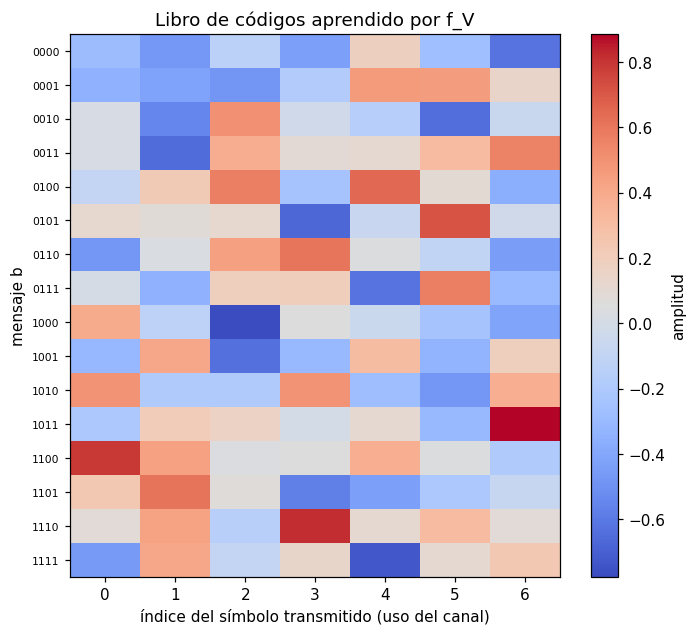

In [ ]:
# ----------------------------------------------------------------------------------------
#  ¿Qué código aprendió la red?  Libro de códigos, energía y distancia mínima
# ----------------------------------------------------------------------------------------
with torch.no_grad():
    msgs = all_messages(K).to(device)
    cw = model.encoder(msgs)                                   # (2^K, n): todas las palabras código

print(f"Energía media por palabra código: {cw.pow(2).sum(dim=1).mean().item():.4f}   (restricción: E[||x||²] ≤ {POWER})")

def d_min_sq(codebook):
    d = torch.cdist(codebook, codebook)
    d.fill_diagonal_(float("inf"))
    return d.min().item() ** 2

print(f"d²_min (distancia euclídea mínima al cuadrado) del código aprendido: {d_min_sq(cw):.3f}")
if HAS_HAMMING:
    print(f"d²_min de Hamming(7,4) con BPSK y energía {POWER} por palabra: "
          f"{d_min_sq(HAM_BPSK / math.sqrt(N_CH) * math.sqrt(POWER)):.3f}   (= 4·3/7·P)")
print("Nota: d²_min gobierna el comportamiento a SNR alto, pero no lo es todo (importa también cuántos vecinos "
      "hay a esa distancia y el SNR con el que se entrenó).")

if K <= 6:
    fig, ax = plt.subplots(figsize=(6.5, 0.28 * 2 ** K + 1.4))
    im = ax.imshow(cw.cpu().numpy(), aspect="auto", cmap="coolwarm")
    ax.set_yticks(range(2 ** K)); ax.set_yticklabels([format(i, f"0{K}b") for i in range(2 ** K)], fontsize=7)
    ax.set_xticks(range(N_CH))
    ax.set_xlabel("índice del símbolo transmitido (uso del canal)"); ax.set_ylabel("mensaje b")
    ax.set_title("Libro de códigos aprendido por f_V"); ax.grid(False)
    plt.colorbar(im, ax=ax, label="amplitud")
    plt.tight_layout(); plt.show()

### 5.2 Visualización: transmisión de imágenes MNIST

Ahora la imagen binarizada (784 bits) se parte en bloques y se transmite. Para cada $E_b/N_0$ mostramos:

* **a)** la imagen original,
* **b)** la imagen transmitida **sin codificación** (BPSK sobre AWGN, decisión dura por bit),
* **c)** la imagen reconstruida tras pasar por el **autoencoder de canal**.

Cada bit erróneo es un píxel invertido (ruido "sal y pimienta"). Ambos sistemas usan **la misma $E_b/N_0$**, es decir, la misma energía por bit de información; el autoencoder gasta esa energía repartida en $n=7$ símbolos en lugar de $K=4$. Cambia `IMG_INDEX` y `SNR_LIST` para explorar.

Dígito transmitido: 7


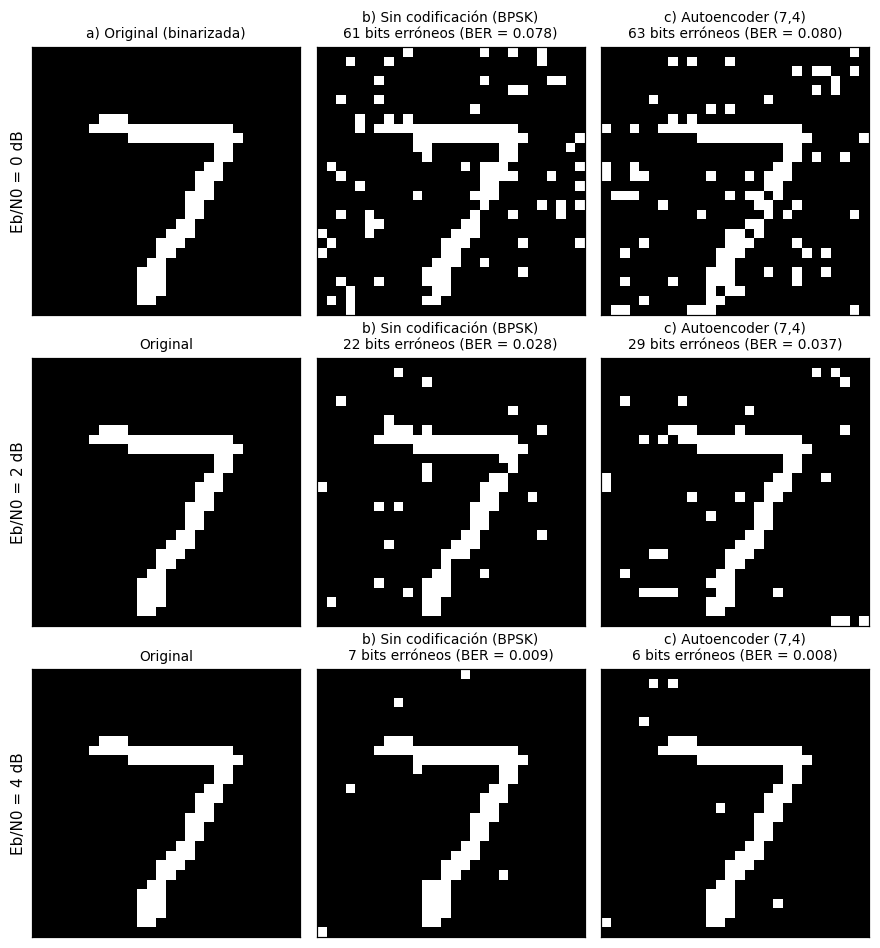

In [ ]:
@torch.no_grad()
def transmit_image(img_bits, scheme, ebn0_db):
    """Transmite una imagen binaria (28x28) por el esquema dado. Devuelve (imagen recibida, nº de bits erróneos)."""
    blocks = bits_to_blocks(img_bits[None]).reshape(-1, K).float().to(device)   # (n_bloques, K)
    est = scheme(blocks, float(ebn0_db))                                        # b̂ para cada bloque
    rec = blocks_to_bits(est.reshape(1, -1, K))[0].cpu()                        # (28, 28)
    n_err = int((rec != img_bits.float()).sum().item())
    return rec.numpy(), n_err


def show_transmission(img_idx, ebn0_list, schemes, names):
    """Filas = valores de Eb/N0; columnas = original + un sistema por columna."""
    img = test_bits[img_idx]
    ncols = 1 + len(schemes)
    fig, axes = plt.subplots(len(ebn0_list), ncols, figsize=(2.7 * ncols, 2.9 * len(ebn0_list)), squeeze=False)
    for r, snr in enumerate(ebn0_list):
        axes[r, 0].imshow(img.numpy(), cmap="gray", vmin=0, vmax=1)
        axes[r, 0].set_title("a) Original (binarizada)" if r == 0 else "Original", fontsize=9)
        axes[r, 0].set_ylabel(f"Eb/N0 = {snr:g} dB", fontsize=10)
        for c, (sch, name) in enumerate(zip(schemes, names), start=1):
            rec, n_err = transmit_image(img, sch, snr)
            axes[r, c].imshow(rec, cmap="gray", vmin=0, vmax=1)
            axes[r, c].set_title(f"{name}\n{n_err} bits erróneos (BER = {n_err / IMG_PIXELS:.3f})", fontsize=9)
    for ax in axes.ravel():
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    plt.tight_layout(); plt.show()


torch.manual_seed(SEED + 3)
IMG_INDEX = 0                    # índice de la imagen en el conjunto de prueba
SNR_LIST  = [0.0, 2.0, 4.0]      # Eb/N0 (dB): a SNR alto casi no se ven errores sin codificar

print(f"Dígito transmitido: {int(test_labels[IMG_INDEX])}")
show_transmission(IMG_INDEX, SNR_LIST,
                  schemes=[make_uncoded_scheme(ChannelLayer(1, 1.0, "awgn")), make_ae_scheme(model)],
                  names=["b) Sin codificación (BPSK)", f"c) Autoencoder ({N_CH},{K})"])

### 5.3 Prueba de robustez: ruido en ráfagas (canal no AWGN)

El decodificador de máxima verosimilitud de Hamming (y, en general, todo el diseño clásico de mínima distancia) es óptimo **para ruido gaussiano blanco**. Con ruido en ráfagas, la mezcla de varianzas cambia la regla óptima: un símbolo "muy grande" durante una ráfaga aporta poca información fiable, algo que un receptor de mínima distancia no sabe explotar. No existe un código de libro de texto sencillo para este canal, pero **el enfoque end-to-end no lo necesita**: basta con poder *muestrear* el canal.

Haremos dos pruebas con el canal de ráfagas definido en la sección 3.3 (misma potencia media de ruido que AWGN):

1. **Robustez sin reentrenar**: evaluamos el autoencoder entrenado en AWGN directamente sobre el canal con ráfagas.
2. **Adaptación**: se *continúa el entrenamiento* del mismo modelo, ahora con el canal de ráfagas dentro del lazo de entrenamiento, **sin cambiar nada más** (ni la arquitectura, ni la pérdida, ni un modelo analítico del ruido).

**Advertencias para interpretar los resultados**

* A igual potencia media, el ruido en ráfagas puede ser *más benigno* que AWGN a $E_b/N_0$ bajo (casi todo el "presupuesto de ruido" se gasta en pocos símbolos que ya se habrían perdido) y **mucho peor a $E_b/N_0$ alto**, donde las ráfagas dominan los errores y aparece un **piso de error**. Esto es consecuencia de la convexidad de $Q(\cdot)$ y no un error de simulación.
* Un código de longitud $n=7$ **no puede** corregir ráfagas arbitrariamente largas; lo que se espera del modelo adaptado es una **reducción** del BER respecto al modelo AWGN (y quizá del piso de error), no su eliminación. La magnitud de la mejora depende de `BURST_*` y de los hiperparámetros: experimenta.
* El modelo adaptado puede **perder algo de rendimiento en AWGN**: se ha especializado. Lo comprobamos en el panel derecho.

Adaptando el modelo al canal con ráfagas (8000 iteraciones) ...
  paso      1/8000 | BCE = 0.0967 | BER (lote) = 0.0234 |   0.0 s
  paso   2500/8000 | BCE = 0.0492 | BER (lote) = 0.0178 |   7.2 s
  paso   5000/8000 | BCE = 0.0424 | BER (lote) = 0.0154 |  14.3 s
  paso   7500/8000 | BCE = 0.0407 | BER (lote) = 0.0146 |  21.6 s
Simulación terminada en 0.2 s


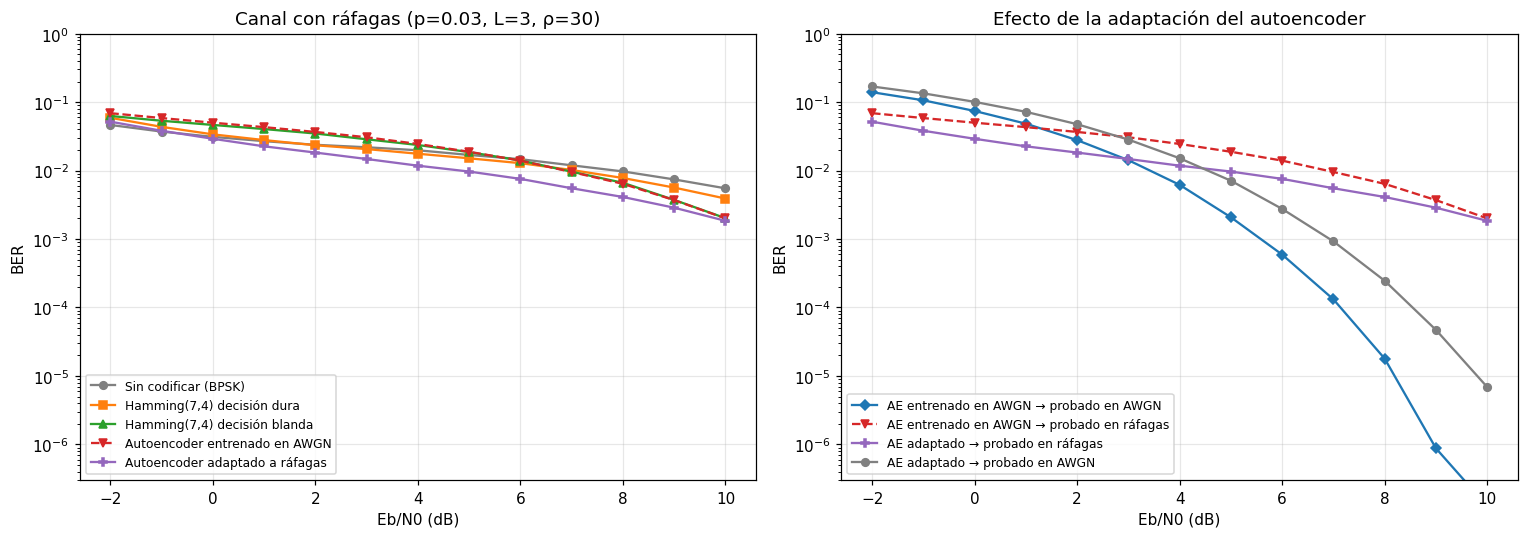


BER en canal con ráfagas
Eb/N0[dB] |       Sin codificar (BPSK) | Hamming(7,4) decisión dura | Hamming(7,4) decisión blan | Autoencoder entrenado en A | Autoencoder adaptado a ráf
     -2.0 |                   4.64e-02 |                   5.91e-02 |                   6.28e-02 |                   6.89e-02 |                   5.18e-02
     -1.0 |                   3.71e-02 |                   4.35e-02 |                   5.34e-02 |                   5.85e-02 |                   3.82e-02
      0.0 |                   3.11e-02 |                   3.38e-02 |                   4.64e-02 |                   5.00e-02 |                   2.91e-02
      1.0 |                   2.69e-02 |                   2.79e-02 |                   4.04e-02 |                   4.31e-02 |                   2.26e-02
      2.0 |                   2.38e-02 |                   2.34e-02 |                   3.48e-02 |                   3.67e-02 |                   1.83e-02
      3.0 |                   2.19e-02 |    

In [ ]:
# ----------------------------------------------------------------------------------------
#  5.3  Canal con ráfagas: robustez y adaptación
# ----------------------------------------------------------------------------------------
def burst_ch(k_bits, block_energy):
    return ChannelLayer(k_bits, block_energy, "burst", BURST_P, BURST_LEN, BURST_RATIO)

# (1) Robustez sin reentrenar: el modelo AWGN sobre el canal con ráfagas
ae_on_burst = make_ae_scheme(model, burst_ch(K, POWER))

# (2) Adaptación: continuar el entrenamiento con el canal de ráfagas dentro del lazo
model_adapt = copy.deepcopy(model)
model_adapt.channel = burst_ch(K, POWER)
print(f"Adaptando el modelo al canal con ráfagas ({ADAPT_STEPS} iteraciones) ...")
torch.manual_seed(SEED + 4)
hist_adapt = train_autoencoder(model_adapt, TRAIN_EBN0_DB, ADAPT_STEPS, BATCH_SIZE, LR * 0.5, TRAIN_SOURCE)
ae_adapt          = make_ae_scheme(model_adapt)                                  # usa su canal de ráfagas
ae_adapt_on_awgn  = make_ae_scheme(model_adapt, ChannelLayer(K, POWER, "awgn"))  # ¿qué pasa en AWGN?

# --- Curvas BER ---
torch.manual_seed(SEED + 5)
t0 = time.time()
curves_burst = {}
curves_burst["Sin codificar (BPSK)"] = (ber_curve(make_uncoded_scheme(burst_ch(1, 1.0)), EBN0_GRID), "unc")
if HAS_HAMMING:
    ch_ham_b = burst_ch(4, 7.0)
    curves_burst["Hamming(7,4) decisión dura"]   = (ber_curve(make_hamming_scheme(ch_ham_b, "hard"), EBN0_GRID), "ham_hard")
    curves_burst["Hamming(7,4) decisión blanda"] = (ber_curve(make_hamming_scheme(ch_ham_b, "soft"), EBN0_GRID), "ham_soft")
curves_burst["Autoencoder entrenado en AWGN"]          = (ber_curve(ae_on_burst, EBN0_GRID), "ae_burst")
curves_burst["Autoencoder adaptado a ráfagas"]         = (ber_curve(ae_adapt, EBN0_GRID), "ae_adapt")
print(f"Simulación terminada en {time.time() - t0:.1f} s")

curves_cmp = {
    "AE entrenado en AWGN → probado en AWGN":        (curves_awgn[f"Autoencoder ({N_CH},{K})  [entrenado a {TRAIN_EBN0_DB:g} dB]"][0], "ae"),
    "AE entrenado en AWGN → probado en ráfagas":     (curves_burst["Autoencoder entrenado en AWGN"][0], "ae_burst"),
    "AE adaptado → probado en ráfagas":              (curves_burst["Autoencoder adaptado a ráfagas"][0], "ae_adapt"),
    "AE adaptado → probado en AWGN":                 (ber_curve(ae_adapt_on_awgn, EBN0_GRID), "unc"),
}

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_ber(ax[0], EBN0_GRID, curves_burst,
         f"Canal con ráfagas (p={BURST_P}, L={BURST_LEN}, ρ={BURST_RATIO:g})")
plot_ber(ax[1], EBN0_GRID, curves_cmp, "Efecto de la adaptación del autoencoder")
plt.tight_layout(); plt.show()

names = list(curves_burst.keys())
print("\nBER en canal con ráfagas")
print("Eb/N0[dB] | " + " | ".join(f"{n[:26]:>26}" for n in names))
for i, g in enumerate(EBN0_GRID):
    print(f"{g:9.1f} | " + " | ".join(f"{curves_burst[n][0][i]:26.2e}" for n in names))

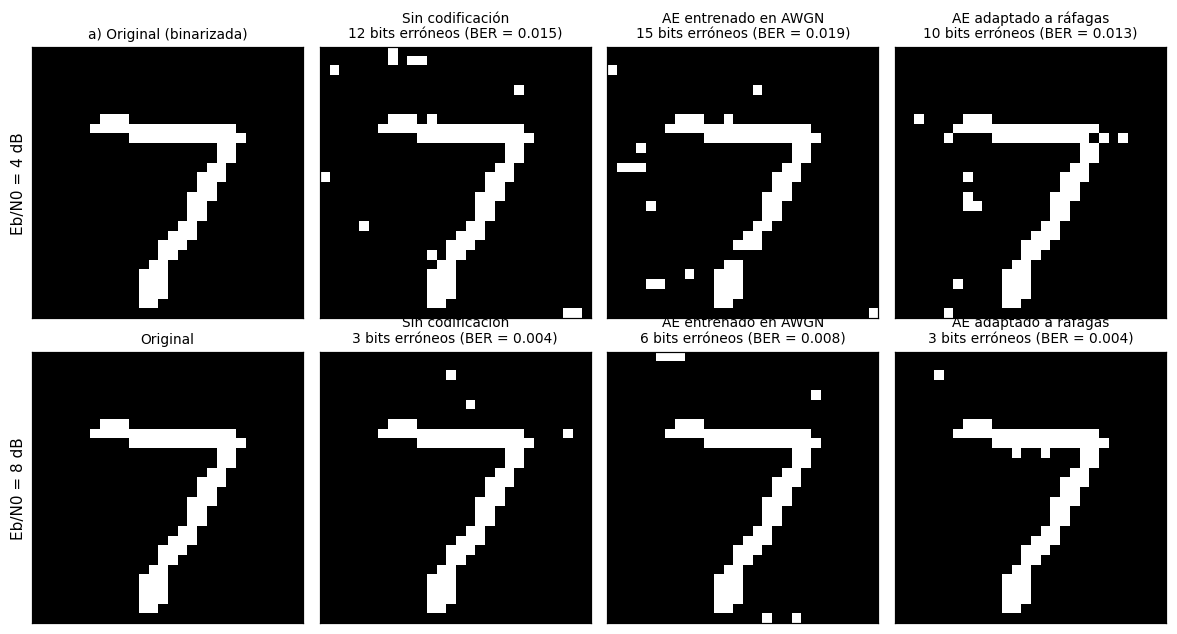

In [ ]:
# ----------------------------------------------------------------------------------------
#  Imágenes bajo ruido en ráfagas
# ----------------------------------------------------------------------------------------
torch.manual_seed(SEED + 6)
SNR_LIST_BURST = [4.0, 8.0]
show_transmission(IMG_INDEX, SNR_LIST_BURST,
                  schemes=[make_uncoded_scheme(burst_ch(1, 1.0)), ae_on_burst, ae_adapt],
                  names=["Sin codificación", "AE entrenado en AWGN", "AE adaptado a ráfagas"])